In [ ]:
import pandas as pd
import geopandas as gpd
from google.colab import drive
import matplotlib.pyplot as plt
from shapely.geometry import Point
import seaborn as sns
#import contextily as ctx
import numpy as np
import random
from scipy.spatial import cKDTree

drive.mount('/content/drive')

#Bases de datos originales

df1 = gpd.read_file('/content/drive/MyDrive/limitespdq.geojson')
df2 = pd.read_csv('/content/drive/MyDrive/actes-criminels.csv')
df3 = gpd.read_file('/content/drive/MyDrive/estacion_policias.geojson')


Mounted at /content/drive


In [ ]:
df2

,CATEGORIE,DATE,QUART,PDQ,X,Y,LONGITUDE,LATITUDE
0,Vol de véhicule à moteur,2018-09-13,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780
1,Vol de véhicule à moteur,2018-04-30,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780
2,Vol de véhicule à moteur,2018-09-01,nuit,7.0,290274.565000,5.042150e+06,-73.685928,45.519122
3,Méfait,2017-07-21,jour,21.0,NaN,NaN,NaN,NaN
4,Méfait,2017-07-29,jour,12.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
244112,Introduction,2022-09-30,jour,20.0,NaN,NaN,NaN,NaN
244113,Vol de véhicule à moteur,2022-09-30,jour,9.0,292261.027997,5.035706e+06,-73.660337,45.461170
244114,Méfait,2022-09-30,soir,20.0,NaN,NaN,NaN,NaN
244115,Vol dans / sur véhicule à moteur,2022-10-01,soir,26.0,295209.489996,5.041044e+06,-73.622739,45.509253


In [ ]:
!pip install geoplot
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 71.8 MB/s eta 0:00:00


In [ ]:
#A las instancias con PDQ faltante le asignamos la estacion mas cercana en el mapa


crimenes_sin_pdq = df2[df2['PDQ'].isna()].copy()

print(crimenes_sin_pdq)

# 2. Extraer coordenadas
#coords_crimenes = crimenes_sin_pdq[['LATITUDE', 'LONGITUDE']].to_numpy()
coords_crimenes = crimenes_sin_pdq[['X','Y']].to_numpy()
coords_pdq = df3[['LATITUDE', 'LONGITUDE']].to_numpy()

print(coords_crimenes)
print(coords_pdq)

# 3. Crear un KDTree para los PDQ
tree = cKDTree(coords_pdq)

# 4. Buscar el PDQ más cercano para cada crimen sin asignar
distancias, indices = tree.query(coords_crimenes, k=1)

# 5. Asignar el PDQ más cercano
crimenes_sin_pdq['PDQ'] = df3.iloc[indices]['PDQ'].values

# 6. Reemplazar en el DataFrame original
df2.loc[df2['PDQ'].isna(), 'PDQ'] = crimenes_sin_pdq['PDQ']

Empty DataFrame
Columns: [CATEGORIE, DATE, QUART, PDQ, X, Y, LONGITUDE, LATITUDE]
Index: []
[]
[['45.49440000020' '-73.80730000050']
 ['45.57770000030' '-73.61739999990']
 ['45.55690000020' '-73.54590000030']
 ['45.52850000000' '-73.70100000040']
 ['45.60769999960' '-73.61560000010']
 ['45.44789999910' '-73.81589999980']
 ['45.48640000080' '-73.59870000000']
 ['45.46370000020' '-73.58500000000']
 ['45.64159999970' '-73.50540000010']
 ['45.53979999940' '-73.60910000000']
 ['45.51840000040' '-73.69670000020']
 ['45.44730000010' '-73.85230000040']
 ['45.43439999970' '-73.67710000000']
 ['45.60500000040' '-73.55300000030']
 ['45.45979999940' '-73.66210000030']
 ['45.51649999990' '-73.56309999990']
 ['45.52549999950' '-73.57519999980']
 ['45.41550000010' '-73.62170000000']
 ['45.52170000040' '-73.55100000000']
 ['45.49609999920' '-73.65160000040']
 ['45.54240000060' '-73.56929999960']
 ['45.56860000080' '-73.65359999980']
 ['45.45920000040' '-73.57330000030']
 ['45.48609999940' '-73.8572000

KeyError: 'PDQ'

**Preprocesamiento de datos**:
Se identifican los tipos de crímenes cometidos

In [ ]:
#df = df2.dropna(subset=['LONGITUDE', 'LATITUDE'])  # eliminar vacíos

categoria = df2['CATEGORIE']
fecha = df2['DATE']
tiempo = df2['QUART']
distritos = df2['PDQ']

crimenes = categoria.unique()


print('Tipo de crimen: ', crimenes)

print('Años que abarca la base de datos: ', fecha.str[:4].unique())

print('Tiempo del día que ocurren: ', tiempo.unique())


Tipo de crimen:  ['Vol de véhicule à moteur' 'Méfait' 'Vols qualifiés'
 'Vol dans / sur véhicule à moteur' 'Introduction'
 'Infractions entrainant la mort']
Años que abarca la base de datos:  ['2018' '2017' '2016' '2015' '2019' '2020' '2021' '2022' '2023']
Tiempo del día que ocurren:  ['jour' 'nuit' 'soir']


**Gráficas**

<GeoAxes: >

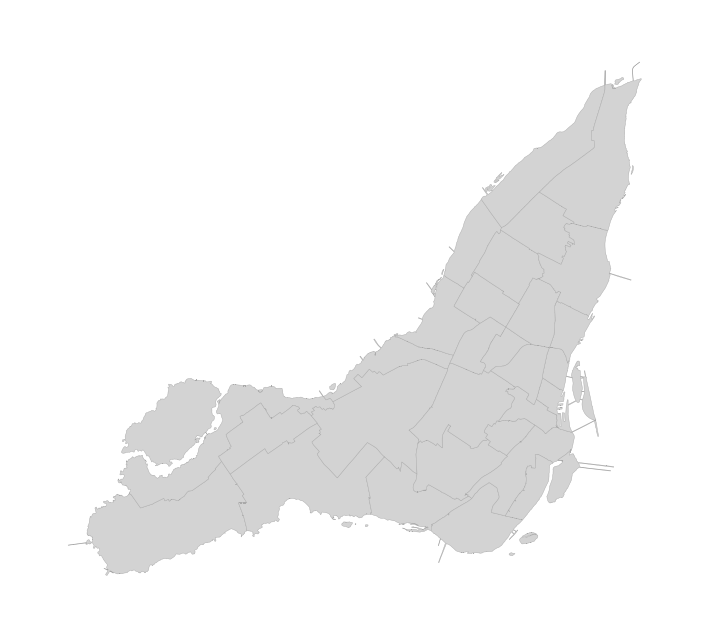

In [ ]:
#cartograma
import geoplot
import geoplot.crs as gcrs

geoplot.polyplot(
    df1,
    projection=gcrs.AlbersEqualArea(),
    edgecolor='darkgrey',
    facecolor='lightgrey',
    linewidth=.3,
    figsize=(12, 8)
)

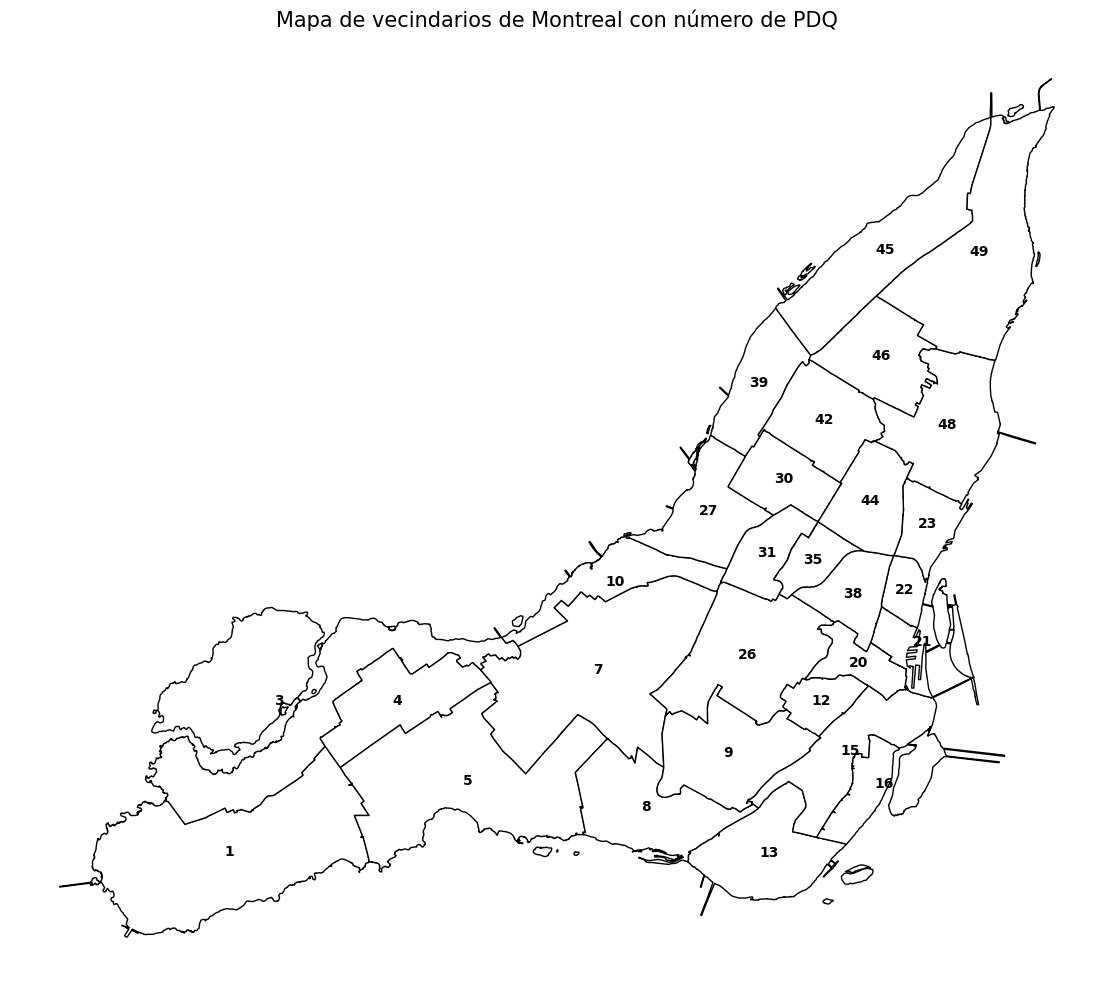

In [ ]:
# Crear el mapa
fig, ax = plt.subplots(figsize=(12, 10))
df1.plot(ax=ax, edgecolor='black', facecolor='white', linewidth=1)

# Escribir los números de PDQ en los centroides
for idx, row in df1.iterrows():
    if row['geometry'].centroid.is_empty:
        continue
    x, y = row['geometry'].centroid.coords[0]
    ax.text(x, y, str(row['PDQ']), fontsize=10, ha='center', va='center', weight='bold')
#    ax.text(x, y - 0.001, row['NOM_PDQ'], fontsize=8, ha='center', va='top', color='gray')


ax.set_title("Mapa de vecindarios de Montreal con número de PDQ", fontsize=15)
ax.axis("off")
plt.tight_layout()
plt.show()

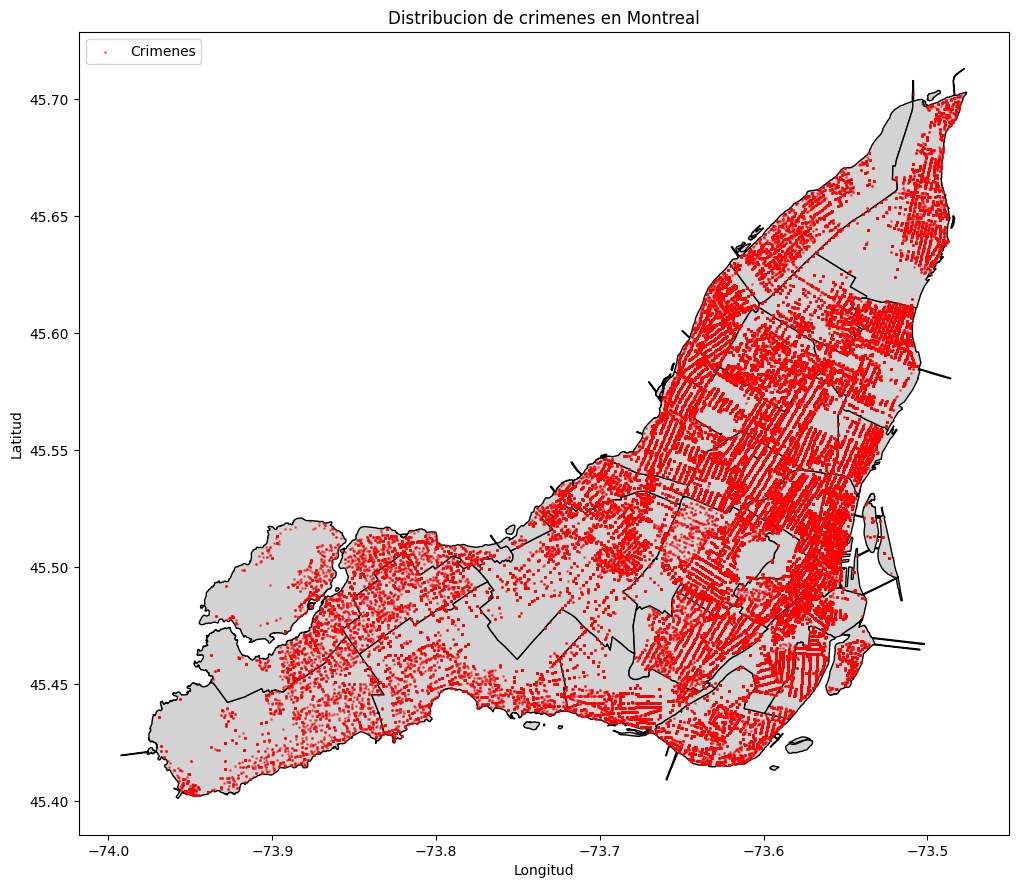

In [ ]:
#Creamos geometria a partir de coordenadas
geometry = [Point(xy) for xy in zip(df2['LONGITUDE'], df2['LATITUDE'])]

#Creamos GeoDataFrame
crimenes_geo = gpd.GeoDataFrame(df2, geometry=geometry, crs="EPSG:4326")  # WGS84

#Nos aseguramos de que el mapa también este en WGS84
mapa = df1.to_crs("EPSG:4326")

#Dibujamos el mapa
fig, ax = plt.subplots(figsize=(12, 12))
mapa.plot(ax=ax, color='lightgrey', edgecolor='black')

#Dibujamos los puntos de crimen
crimenes_geo.plot(ax=ax, markersize=1, color='red', alpha=0.5,label="Crimenes")

plt.legend(loc="upper left")
plt.title("Distribucion de crimenes en Montreal")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

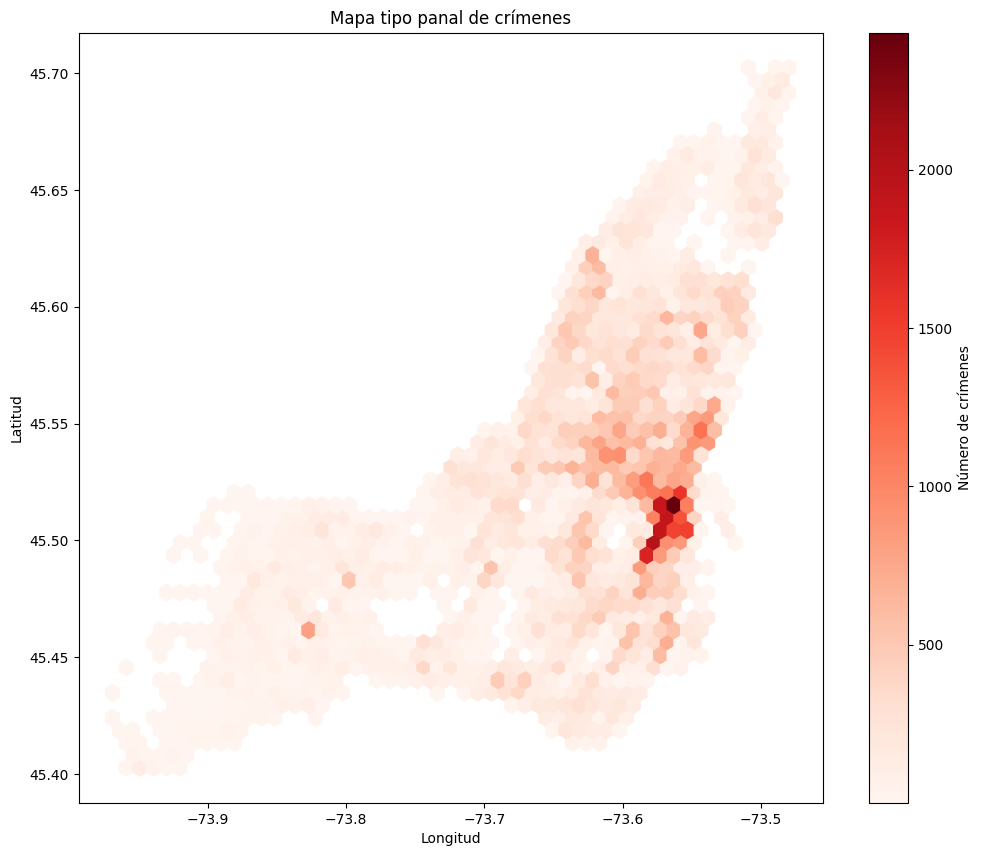

In [ ]:
#Grafico tipo panal para visualizar la densidad de crimenes


coords = df2.dropna(subset=['LONGITUDE', 'LATITUDE'])

plt.figure(figsize=(12, 10))
plt.hexbin(
    coords['LONGITUDE'],
    coords['LATITUDE'],
    gridsize=50,
    cmap='Reds',
    mincnt=1
)
plt.colorbar(label='Número de crímenes')
plt.title('Mapa tipo panal de crímenes')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

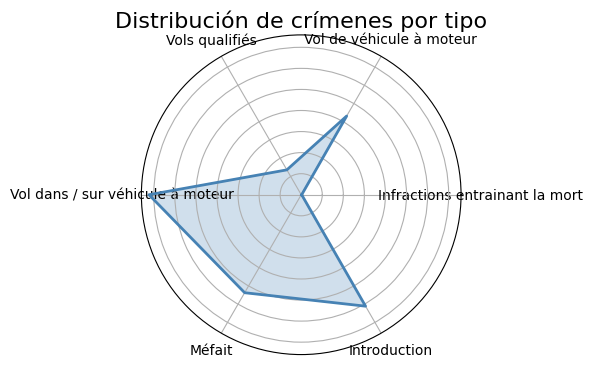

In [ ]:
# Contar los tipos de crimen
categoria_counts = df2['CATEGORIE'].value_counts()

# Mezclar el orden de las categorías
categories = list(categoria_counts.index)
random.shuffle(categories)

# Obtener los valores correspondientes
values = [categoria_counts[category] for category in categories]

# Número de variables (categorías)
num_vars = len(categories)

# Dividir el círculo en secciones (una por categoría)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# El gráfico de radar necesita que la primera categoría se repita al final para cerrar el gráfico
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

# Crear el gráfico
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, values, color='steelblue', alpha=0.25)  # Área sombreada
ax.plot(angles, values, color='steelblue', linewidth=2)  # Líneas

# Añadir etiquetas
ax.set_yticklabels([])  # Eliminar etiquetas del eje radial
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, rotation=45)

# Título
plt.title('Distribución de crímenes por tipo', size=16)

plt.tight_layout()
plt.show()

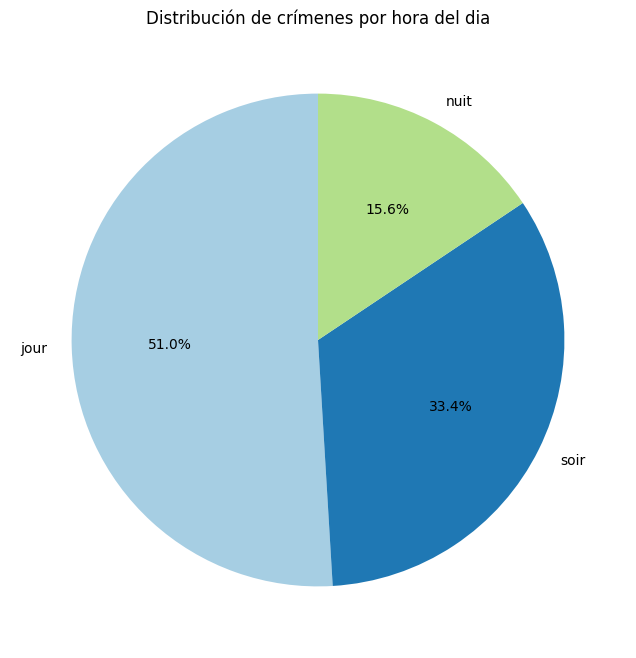

In [ ]:
categoria_counts = df2['QUART'].value_counts()

# Crear gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(categoria_counts, labels=categoria_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Título
plt.title('Distribución de crímenes por hora del dia')

plt.show()

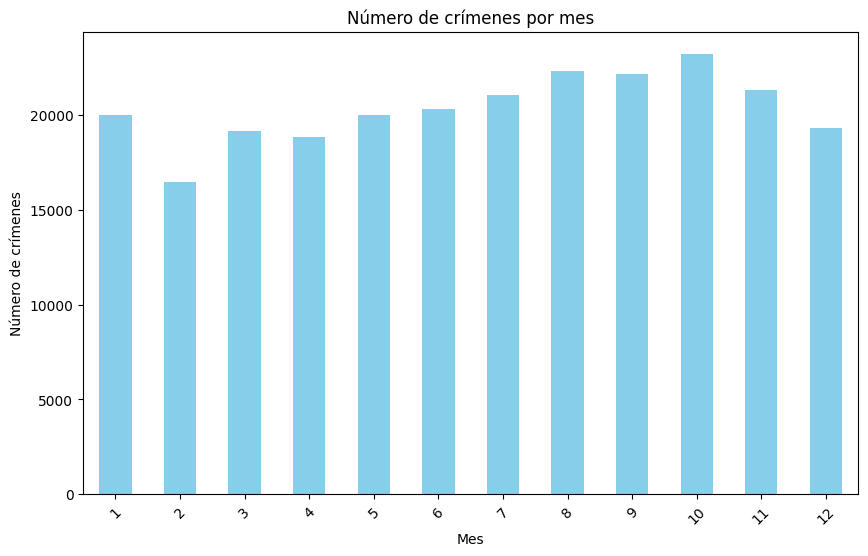

In [ ]:
# Asegúrate de que la columna 'DATE' esté en formato de fecha
df2['DATE'] = pd.to_datetime(df2['DATE'], errors='coerce')

# Crear una nueva columna 'year_month' para agrupar por año y mes
df2['month'] = df2['DATE'].dt.month

# Contar los crímenes por mes
crimenes_por_mes = df2.groupby('month').size()

plt.figure(figsize=(10, 6))
crimenes_por_mes.plot(kind='bar', color='skyblue')

plt.title('Número de crímenes por mes')
plt.xlabel('Mes')
plt.ylabel('Número de crímenes')
plt.xticks(rotation=45)  # Rotar las etiquetas del eje X para que se vean bien
plt.show()

In [ ]:
crimenes_PDQ = df2['PDQ']

coords = crimenes_PDQ.dropna(subset=['LONGITUDE', 'LATITUDE'])

plt.figure(figsize=(12, 10))
plt.hexbin(
    coords['LONGITUDE'],
    coords['LATITUDE'],
    gridsize=50,
    cmap='Reds',
    mincnt=1
)
plt.colorbar(label='Número de crímenes')
plt.title('Mapa tipo panal de crímenes tipo Méfait')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

TypeError: Series.dropna() got an unexpected keyword argument 'subset'

In [ ]:
# Mapa de clavijas para estaciones de policia
import folium
import geopandas as gpd


centro = [df3.geometry.y.mean(), df3.geometry.x.mean()]
mapa = folium.Map(location=centro, zoom_start=12)

for _, row in df3.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    nombre = row.get('NOM_POSTE', 'Estación de policía')

    folium.Marker(
        location=[lat, lon],
        popup=nombre,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(mapa)

mapa



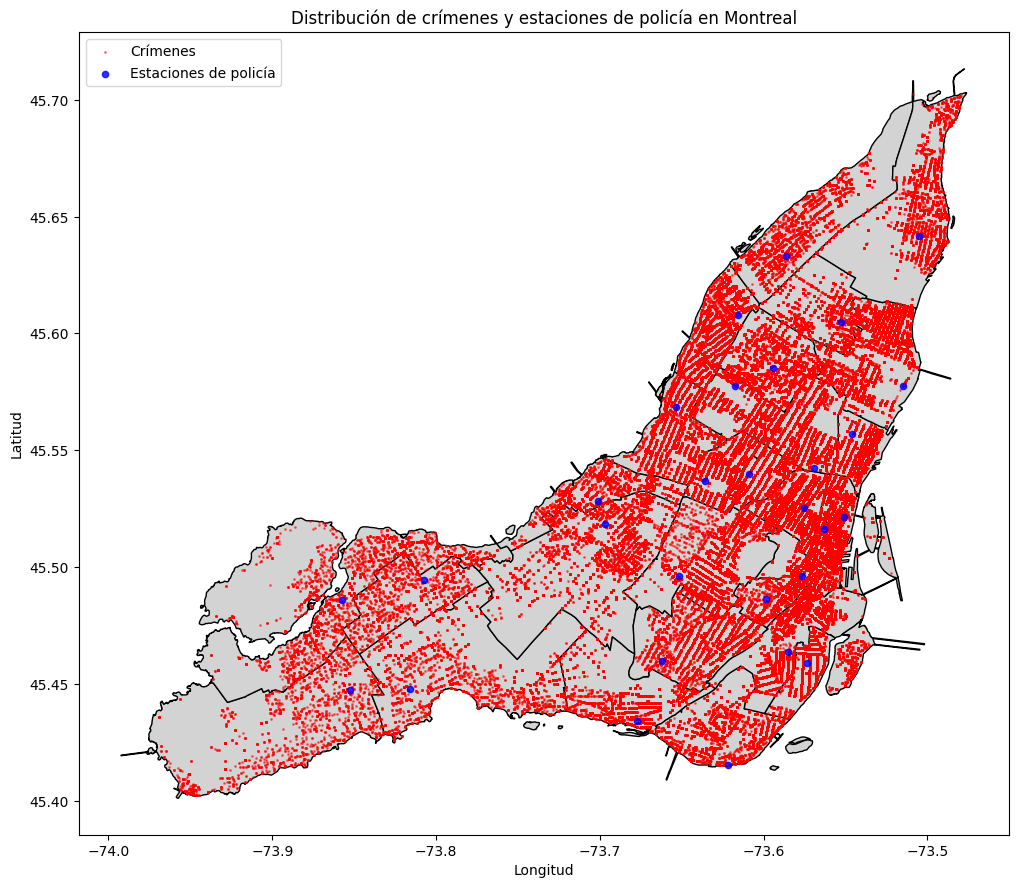

In [ ]:
#Distribución de crimenes comparando con ubicación de estaciones de policia

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


geometry_crimenes = [Point(xy) for xy in zip(df2['LONGITUDE'], df2['LATITUDE'])]
crimenes_geo = gpd.GeoDataFrame(df2, geometry=geometry_crimenes, crs="EPSG:4326")


mapa_base = df1.to_crs("EPSG:4326")


df3 = df3.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(12, 12))
mapa_base.plot(ax=ax, color='lightgrey', edgecolor='black')
crimenes_geo.plot(ax=ax, markersize=1, color='red', alpha=0.5, label="Crímenes")
df3.plot(ax=ax, markersize=20, color='blue', marker='o', alpha=0.8, label="Estaciones de policía")

plt.legend(loc="upper left")
plt.title("Distribución de crímenes y estaciones de policía en Montreal")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


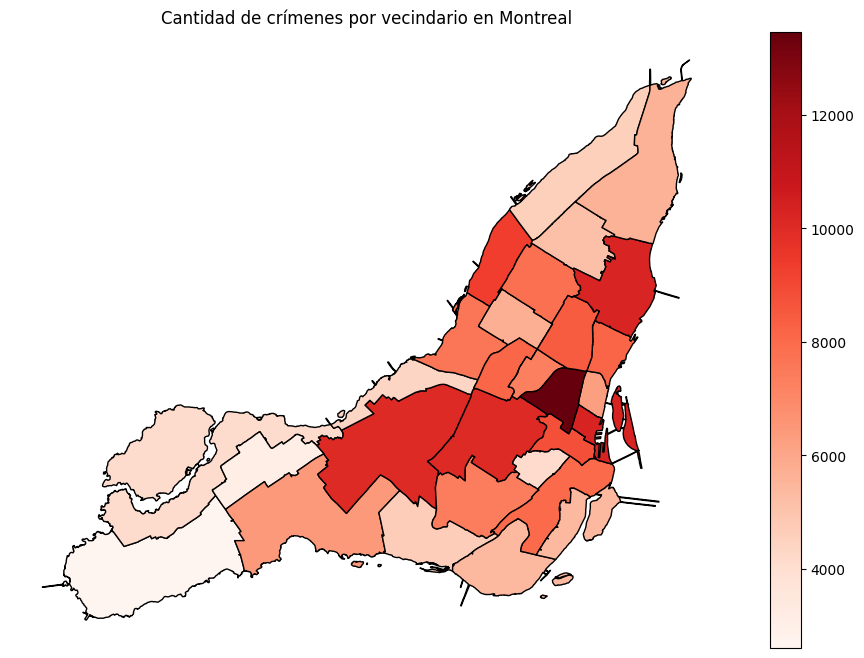

array(['Vol de véhicule à moteur', 'Méfait',
       'Vol dans / sur véhicule à moteur', 'Introduction',
       'Vols qualifiés', 'Infractions entrainant la mort'], dtype=object)

In [ ]:
# Convertir el CSV a GeoDataFrame (asumiendo columnas 'longitude' y 'latitude')
crime_df = df2.dropna(subset=['LONGITUDE', 'LATITUDE'])  # eliminar vacíos
geometry = [Point(xy) for xy in zip(crime_df.LONGITUDE, crime_df.LATITUDE)]
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry, crs="EPSG:4326")

# Spatial join: asignar vecindario a cada crimen
crime_with_neigh= gpd.sjoin(crime_gdf, df1, how="left", predicate="within")

# Agrupar por vecindario
crime_counts = crime_with_neigh.groupby('NOM_PDQ').size().reset_index(name='n_crimes')

# Merge con geometría de los vecindarios
neigh_summary = df1.merge(crime_counts, on='NOM_PDQ', how='left').fillna(0)

# Visualización: mapa de crímenes por vecindario
neigh_summary.plot(column='n_crimes', cmap='Reds', legend=True, edgecolor='black', figsize=(12, 8))
plt.title("Cantidad de crímenes por vecindario en Montreal")
plt.axis("off")
plt.show()

crime_with_neigh['CATEGORIE'].unique()



[13464 10316 10279 10055 10055  9330  8824  8454  8190  8150  8019  7843
  7613  7362  7284  6451  6265  5737  5636  5396  5384  5181  4659  4555
  4362  4143  4089  3077  2599]


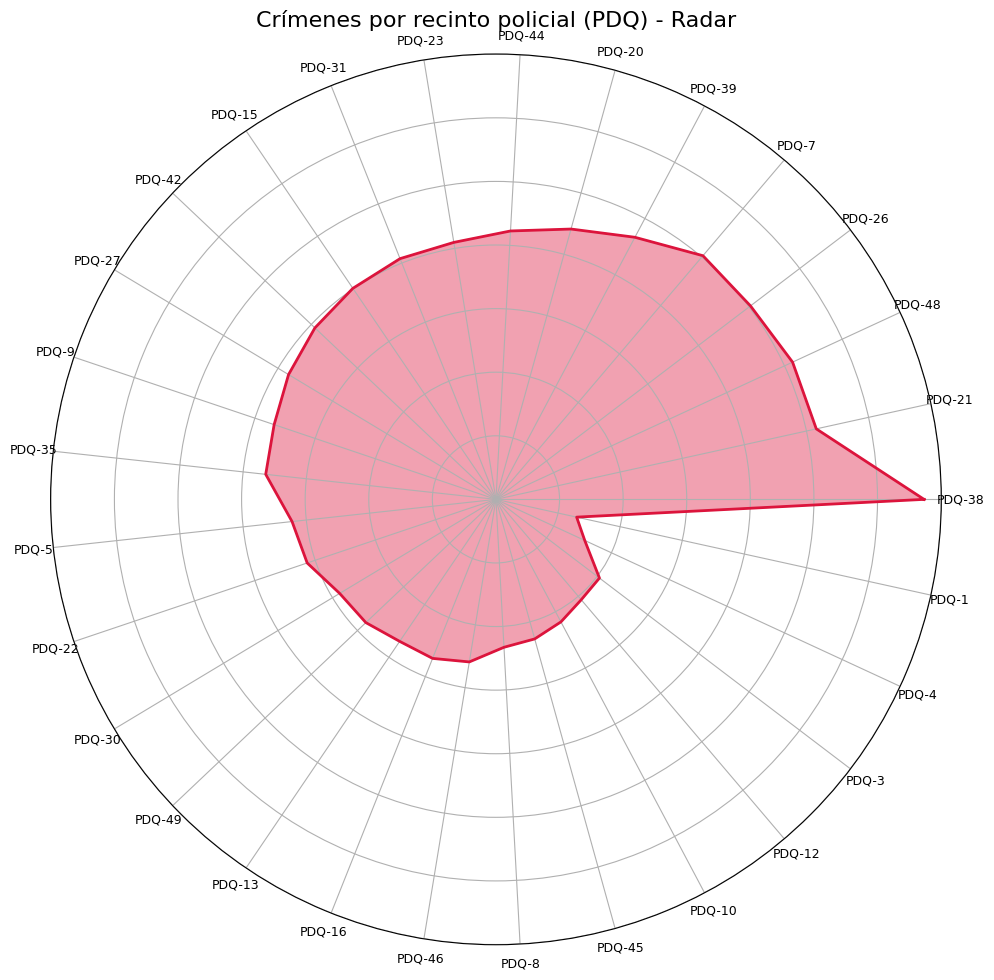

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point

# --- 1. Preparar GeoDataFrame de crímenes ---
crime_df = df2.dropna(subset=['LONGITUDE', 'LATITUDE'])
geometry = [Point(xy) for xy in zip(crime_df.LONGITUDE, crime_df.LATITUDE)]
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry, crs="EPSG:4326")

# --- 2. Unión espacial para asignar vecindarios ---
crime_with_neigh = gpd.sjoin(crime_gdf, df1, how="left", predicate="within")

# --- 3. Agrupar por nombre del PDQ ---
crime_counts = crime_with_neigh.groupby('NOM_PDQ').size().reset_index(name='n_crimes')

# Ordenar por cantidad para consistencia visual
crime_counts = crime_counts.sort_values(by='n_crimes', ascending=False)

# --- 4. Preparar datos para gráfico tipo radar ---
categories = crime_counts['NOM_PDQ']
values = crime_counts['n_crimes'].values
#print(categories)
print(values)

# Cerrar el ciclo del radar (para que el gráfico se cierre correctamente)
values = np.concatenate((values, [values[0]]))
angles = np.linspace(0, 2 * np.pi, len(values), endpoint=True)

# --- 5. Crear gráfico polar tipo radar ---
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Dibujar el gráfico
ax.plot(angles, values, color='crimson', linewidth=2)
ax.fill(angles, values, color='crimson', alpha=0.4)

# Añadir etiquetas
ax.set_xticks(angles[:-1])  # Evita duplicar la primera etiqueta
ax.set_xticklabels(categories, fontsize=9)

# Quitar etiquetas radiales si no se desean
ax.set_yticklabels([])

# Título
plt.title('Crímenes por recinto policial (PDQ) - Radar', size=16, pad=20)

plt.tight_layout()
plt.show()


In [ ]:
from shapely.geometry import Point
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# 1. Limpiar el dataframe original
crime_df = df2.dropna(subset=['LONGITUDE', 'LATITUDE'])

# 2. Convertir a GeoDataFrame
geometry = [Point(xy) for xy in zip(crime_df.LONGITUDE, crime_df.LATITUDE)]
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry, crs="EPSG:4326")

# 3. Hacer el spatial join para asignar el PDQ correcto desde el GeoJSON
crime_with_neigh = gpd.sjoin(crime_gdf, df1, how="left", predicate="within")

# Contar la cantidad de crímenes por cada PDQ del spatial join
pdq_geo_counts = crime_with_neigh['PDQ'].value_counts().sort_index()

# Categorías y valores
categories = pdq_geo_counts.index.astype(str)  # Aseguramos que sean texto
values = pdq_geo_counts.values

# Número de barras
num_vars = len(categories)

# Ángulos
angles = np.linspace(0.0, 2 * np.pi, num_vars, endpoint=False)

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Dibujar las barras
bars = ax.bar(angles, values, width=2*np.pi/num_vars, bottom=0.0, color='crimson', alpha=0.8)

# Etiquetas de PDQ
ax.set_xticks(angles)
ax.set_xticklabels(categories, color='gray', fontsize=10)

# Opcional: quitar etiquetas radiales
ax.set_yticklabels([])

# Título
plt.title('Crímenes por recinto policial (PDQ)\nasignados geográficamente', size=14)

plt.tight_layout()
plt.show()


KeyError: 'PDQ'

In [ ]:
# Vecindarios con más crímenes
top_neigh = crime_with_neigh.groupby('NOM_PDQ').size().sort_values(ascending=False).head(5).index.tolist()

# Filtrar solo los crímenes en esos vecindarios
filtered = crime_with_neigh[crime_with_neigh['NOM_PDQ'].isin(top_neigh)]

# Contar tipos de crimen por vecindario
crime_types = (
    filtered.groupby(['NOM_PDQ', 'CATEGORIE'])
    .size()
    .reset_index(name='count')
    .sort_values(['NOM_PDQ', 'count'], ascending=[True, False])
)

# Mostrar top 5 tipos de crimen por vecindario
top_by_neigh = crime_types.groupby('NOM_PDQ').head(5)
print(top_by_neigh)




   NOM_PDQ                         CATEGORIE  count
3   PDQ-21  Vol dans / sur véhicule à moteur   3781
2   PDQ-21                            Méfait   2539
1   PDQ-21                      Introduction   2372
5   PDQ-21                    Vols qualifiés    879
4   PDQ-21          Vol de véhicule à moteur    735
7   PDQ-26                      Introduction   3181
8   PDQ-26                            Méfait   2297
9   PDQ-26  Vol dans / sur véhicule à moteur   2255
10  PDQ-26          Vol de véhicule à moteur   1708
11  PDQ-26                    Vols qualifiés    606
13  PDQ-38                      Introduction   5843
14  PDQ-38                            Méfait   3106
15  PDQ-38  Vol dans / sur véhicule à moteur   2639
16  PDQ-38          Vol de véhicule à moteur   1216
17  PDQ-38                    Vols qualifiés    651
19  PDQ-48                      Introduction   2740
21  PDQ-48  Vol dans / sur véhicule à moteur   2585
20  PDQ-48                            Méfait   2182
22  PDQ-48  

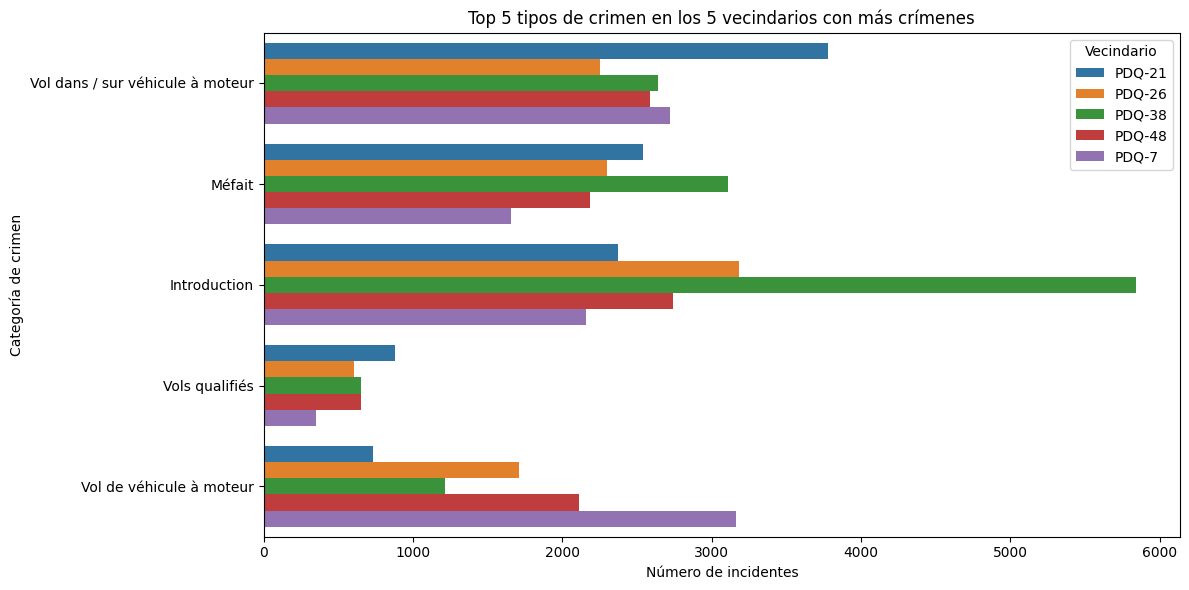

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_by_neigh,
    x='count',
    y='CATEGORIE',
    hue='NOM_PDQ'
)
plt.title("Top 5 tipos de crimen en los 5 vecindarios con más crímenes")
plt.xlabel("Número de incidentes")
plt.ylabel("Categoría de crimen")
plt.legend(title="Vecindario")
plt.tight_layout()
plt.show()


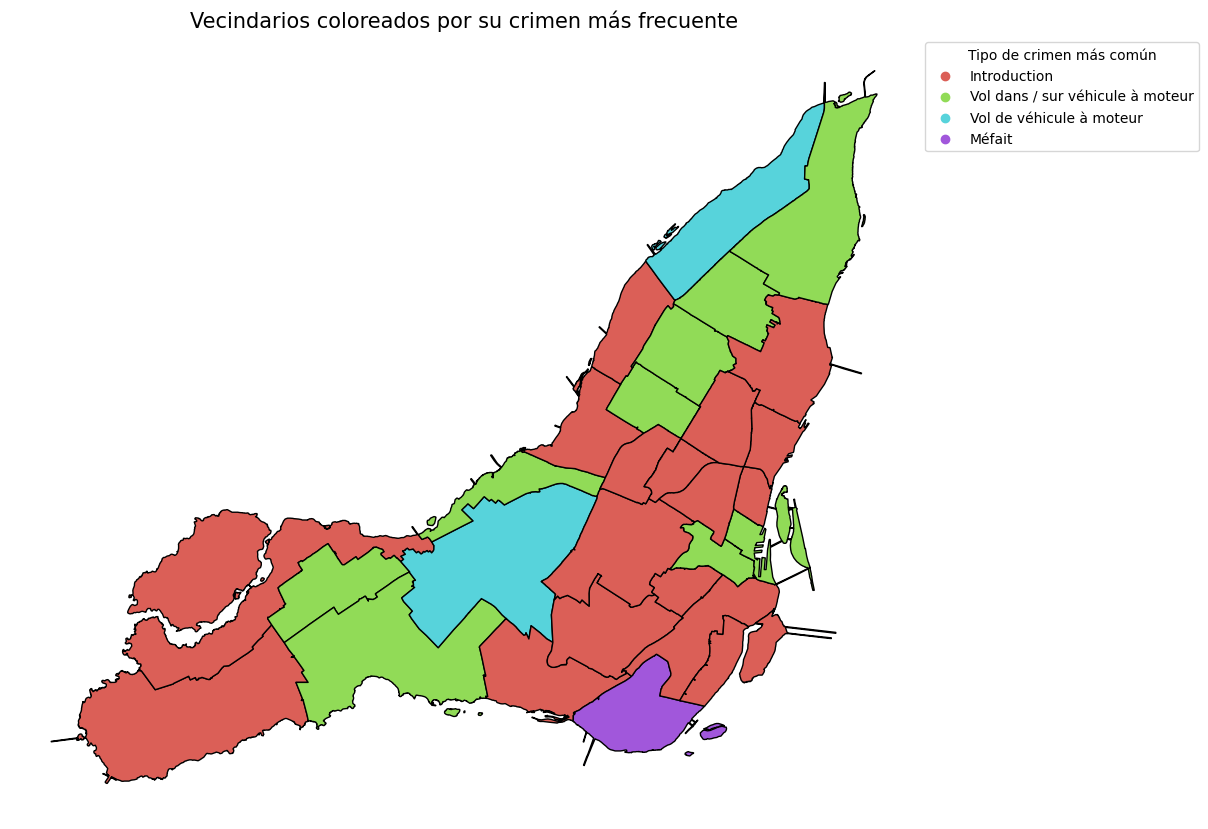

In [ ]:
#mapa vecindarios top de tipo crimen
# 1. Calcular tipo de crimen más común por vecindario
top_crime_per_neigh = (
    crime_with_neigh.groupby(['NOM_PDQ', 'CATEGORIE'])
    .size()
    .reset_index(name='count')
    .sort_values(['NOM_PDQ', 'count'], ascending=[True, False])
    .drop_duplicates('NOM_PDQ')
)

# 2. Unir con geometría
dominant_crime_map = df1.merge(top_crime_per_neigh, on='NOM_PDQ', how='left')

# 3. Asignar un color distinto por tipo de crimen
unique_crimes = dominant_crime_map['CATEGORIE'].dropna().unique()
palette = sns.color_palette("hls", len(unique_crimes))
color_map = dict(zip(unique_crimes, palette))
dominant_crime_map['color'] = dominant_crime_map['CATEGORIE'].map(color_map)

# 4. Dibujar el mapa
fig, ax = plt.subplots(figsize=(12, 10))
dominant_crime_map.plot(ax=ax, color=dominant_crime_map['color'], edgecolor='black')

# Crear leyenda manual
for cat, color in color_map.items():
    ax.scatter([], [], color=color, label=cat)
ax.legend(title="Tipo de crimen más común", loc="upper left", bbox_to_anchor=(1, 1))
ax.set_title("Vecindarios coloreados por su crimen más frecuente", fontsize=15)
ax.axis("off")
plt.tight_layout()
plt.show()

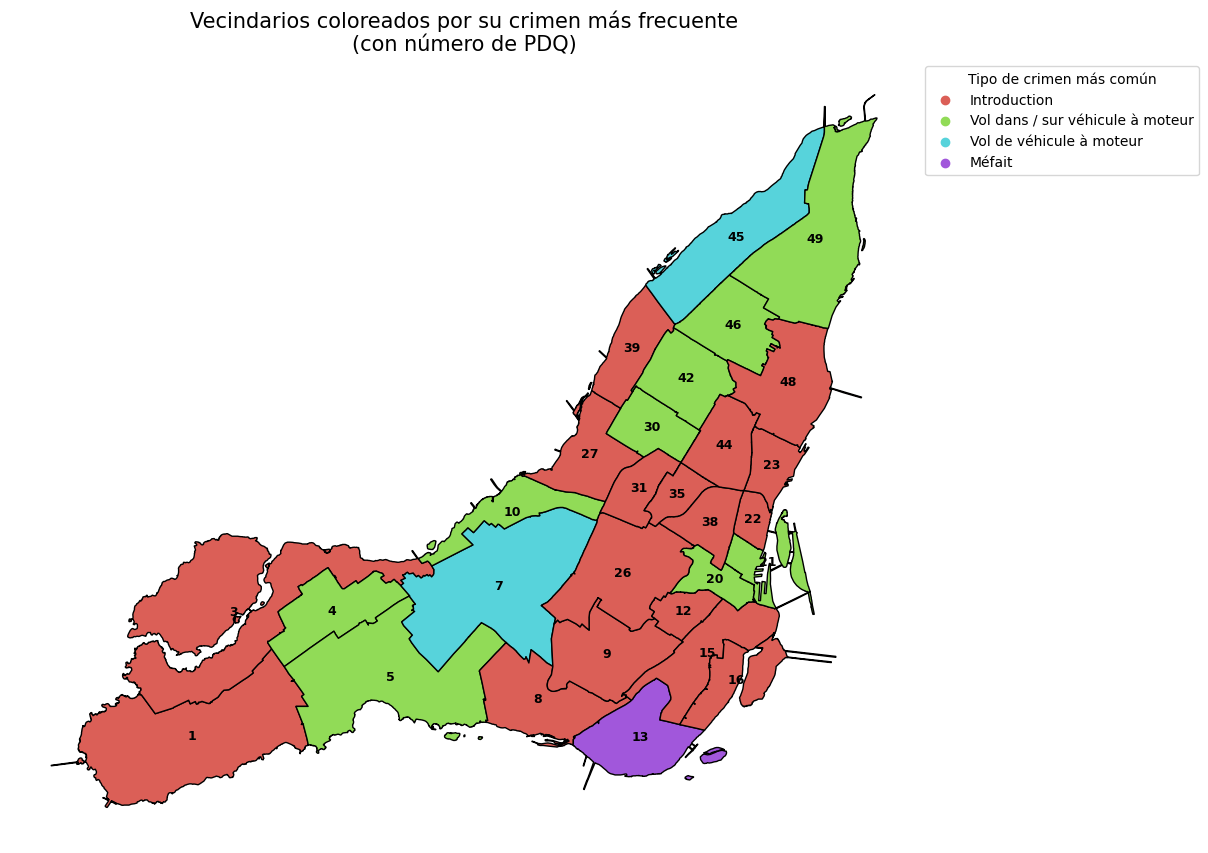

In [ ]:
# Ya tienes dominant_crime_map con la geometría de cada vecindario

fig, ax = plt.subplots(figsize=(12, 10))
dominant_crime_map.plot(ax=ax, color=dominant_crime_map['color'], edgecolor='black')

# Añadir el número de PDQ en el centro de cada vecindario
for idx, row in dominant_crime_map.iterrows():
    if row['geometry'].centroid.is_empty:
        continue
    x, y = row['geometry'].centroid.coords[0]
    ax.text(x, y, str(row['PDQ']), fontsize=9, ha='center', va='center', color='black', weight='bold')

# Leyenda
for cat, color in color_map.items():
    ax.scatter([], [], color=color, label=cat)
ax.legend(title="Tipo de crimen más común", loc="upper left", bbox_to_anchor=(1, 1))
ax.set_title("Vecindarios coloreados por su crimen más frecuente\n(con número de PDQ)", fontsize=15)
ax.axis("off")
plt.tight_layout()
plt.show()


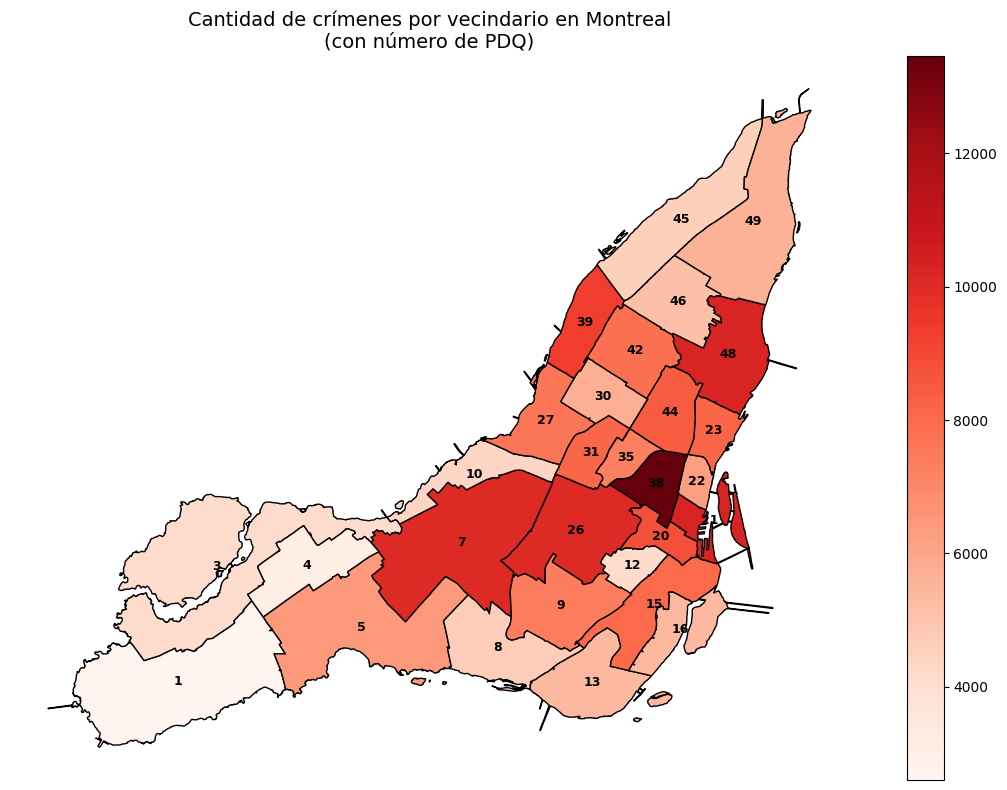

In [ ]:

# Visualización: mapa de crímenes por vecindario con solo el número de PDQ
fig, ax = plt.subplots(figsize=(12, 8))
neigh_summary.plot(column='n_crimes', cmap='Reds', legend=True, edgecolor='black', ax=ax)

# Etiquetar con el número de PDQ
for idx, row in neigh_summary.iterrows():
    if row['geometry'].centroid.is_empty:
        continue
    x, y = row['geometry'].centroid.coords[0]
    ax.text(x, y, str(row['PDQ']), fontsize=9, ha='center', va='center', color='black', weight='bold')

# Título y estilo
ax.set_title("Cantidad de crímenes por vecindario en Montreal\n(con número de PDQ)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()


NameError: name 'crime_with_neigh' is not defined

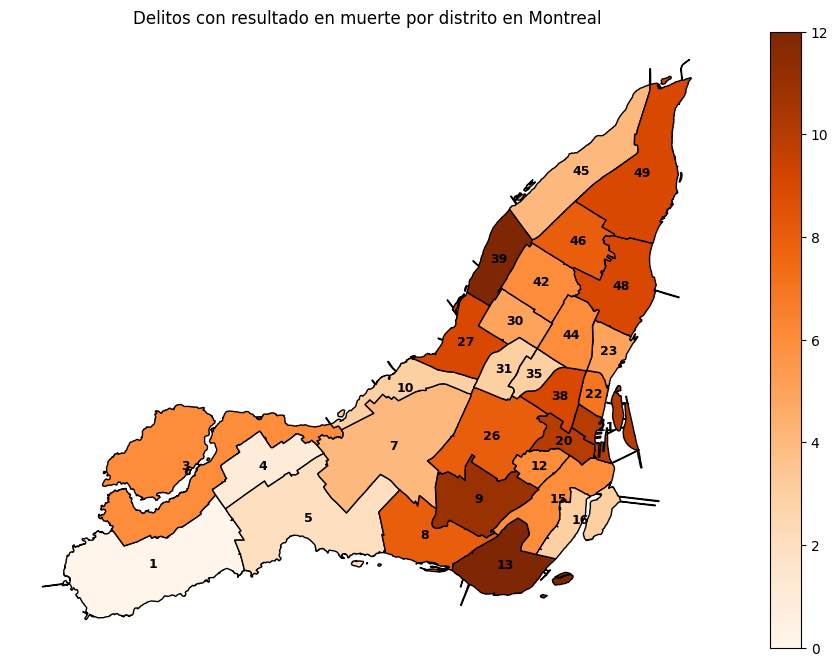

Distrito PDQ-13: 12 delitos fatales
Distrito PDQ-39: 12 delitos fatales
Distrito PDQ-9: 11 delitos fatales
Distrito PDQ-20: 10 delitos fatales
Distrito PDQ-21: 10 delitos fatales
Distrito PDQ-49: 9 delitos fatales
Distrito PDQ-38: 9 delitos fatales
Distrito PDQ-48: 9 delitos fatales
Distrito PDQ-27: 9 delitos fatales
Distrito PDQ-26: 8 delitos fatales
Distrito PDQ-46: 8 delitos fatales
Distrito PDQ-8: 8 delitos fatales
Distrito PDQ-22: 7 delitos fatales
Distrito PDQ-12: 6 delitos fatales
Distrito PDQ-44: 6 delitos fatales
Distrito PDQ-3: 6 delitos fatales
Distrito PDQ-15: 6 delitos fatales
Distrito PDQ-42: 6 delitos fatales
Distrito PDQ-23: 5 delitos fatales
Distrito PDQ-30: 5 delitos fatales
Distrito PDQ-7: 4 delitos fatales
Distrito PDQ-45: 4 delitos fatales
Distrito PDQ-16: 3 delitos fatales
Distrito PDQ-10: 3 delitos fatales
Distrito PDQ-31: 3 delitos fatales
Distrito PDQ-35: 3 delitos fatales
Distrito PDQ-5: 2 delitos fatales
Distrito PDQ-4: 1 delitos fatales


In [ ]:
#Distribución de Delitos con resultado de muerte

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

crime_df = df2.dropna(subset=['LONGITUDE', 'LATITUDE'])
geometry = [Point(xy) for xy in zip(crime_df.LONGITUDE, crime_df.LATITUDE)]
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry, crs="EPSG:4326")

fatal_crimes = crime_gdf[crime_gdf['CATEGORIE'] == 'Infractions entrainant la mort']

fatal_with_neigh = gpd.sjoin(fatal_crimes, df1, how="left", predicate="within")

fatal_counts = fatal_with_neigh.groupby('NOM_PDQ').size().reset_index(name='n_fatal_crimes')

neigh_fatal_summary = df1.merge(fatal_counts, on='NOM_PDQ', how='left').fillna(0)


fig, ax = plt.subplots(figsize=(12, 8))
neigh_fatal_summary.plot(
    column='n_fatal_crimes',
    cmap='Oranges',
    legend=True,
    edgecolor='black',
    ax=ax
)

for idx, row in neigh_fatal_summary.iterrows():
    if row['geometry'].centroid.is_empty:
        continue
    x, y = row['geometry'].centroid.coords[0]
    ax.text(x, y, str(row['PDQ']), fontsize=9, ha='center', va='center', color='black', weight='bold')

plt.title("Delitos con resultado en muerte por distrito en Montreal")
plt.axis("off")
plt.show()



fatal_counts = fatal_counts.sort_values(by='n_fatal_crimes', ascending=False)

for _, row in fatal_counts.iterrows():
    print(f"Distrito {row['NOM_PDQ']}: {int(row['n_fatal_crimes'])} delitos fatales")

